# Phase 5 — SHAP Interpretability: WR

Explains `wr_model.json`'s predictions using SHAP (SHapley Additive exPlanations) on the same training set used to build it, with the same 8 locked features (`config/selected_features.yaml`): `scarcity_z`, `wopr`, `vorp_delta_yoy`, `receiving_epa`, `air_yards_share`, `age`, `draft_pick_inverse`, `target_share`. Same structure and same standard as `08a_shap_qb.ipynb` and `08b_shap_rb.ipynb`, so findings can be compared directly across all three positions rather than read in isolation.

Four things are covered: a global feature-importance view (beeswarm + comparison against gain importance), local explanations for WR's three already-flagged live 2026 predictions (Puka Nacua, Jaxon Smith-Njigba, George Pickens), a reusable `explain_player` function (tested against the two unflagged members of the same top-5 group, Amon-Ra St. Brown and Ja'Marr Chase), and replication checks against QB's two open SHAP mysteries. WR's replication of Mystery 1 carries particular weight: checked directly against `06c_model_wr.ipynb`'s own model-saving cell, `wr_model.json` is trained with `monotone_constraints=NO_CONSTRAINTS` — fully unconstrained on all 8 features, the same setup as `qb_model.json`. That makes WR the first genuine same-tuning-regime replication attempt for Mystery 1; RB's version (`08b_shap_rb.ipynb`) could not cleanly test it, because RB's `vorp_delta_yoy` carries a `+1` monotonic constraint that QB's does not.

## Setup

`shap.TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time by exploiting the tree structure directly, rather than the model-agnostic sampling `KernelExplainer` would require. Applied here to `wr_model.json` and the identical feature matrix `06c_model_wr.ipynb` trained on.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nflreadpy as nfl
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "wopr", "vorp_delta_yoy", "receiving_epa", "air_yards_share", "age", "draft_pick_inverse", "target_share"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
wr = vorp_labels[vorp_labels["position"] == "WR"][
    ["season", "player_id", "player_display_name", "vorp", "vorp_next",
     "wopr", "receiving_epa", "air_yards_share", "target_share"]
].copy()

season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
wr_stats = season_position_stats[season_position_stats["position"] == "WR"]
wr = wr.merge(wr_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
wr["scarcity_z"] = (wr["vorp"] - wr["position_mean_vorp"]) / wr["position_std_vorp_that_season"]
wr = wr.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

prior = wr[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
wr = wr.merge(prior, on=["player_id", "season"], how="left")
wr["vorp_delta_yoy"] = wr["vorp"] - wr["vorp_last_season"]
wr = wr.drop(columns=["vorp_last_season"])

players = nfl.load_players().to_pandas()
wr = wr.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
wr["birth_date"] = pd.to_datetime(wr["birth_date"])
season_start = pd.to_datetime(wr["season"].astype(str) + "-09-01")
wr["age"] = (season_start - wr["birth_date"]).dt.days / 365.25
wr["draft_pick_inverse"] = 1 / wr["draft_pick"]
wr = wr.drop(columns=["gsis_id", "birth_date", "draft_pick"])

wr_2025_features = wr[wr["season"] == 2025].copy()
wr = wr.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"WR training rows: {len(wr)}")

model = xgb.XGBRegressor()
model.load_model(str(REPO_ROOT / "data" / "models" / "wr_model.json"))

explainer = shap.TreeExplainer(model)
shap_values = explainer(wr[FEATURES])
print(f"SHAP values computed: {shap_values.values.shape}")
print(f"Base value (expected model output over the training set): {explainer.expected_value:.3f}")


C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WR training rows: 2731
SHAP values computed: (2731, 8)
Base value (expected model output over the training set): -58.157


## Global summary

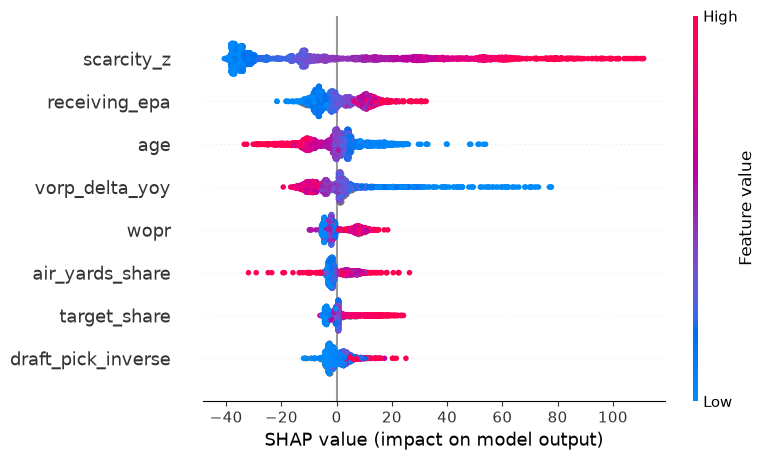

In [2]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()


**Figure 1.** SHAP beeswarm plot, all WR training rows. Each point is one player-season; horizontal position is that row's SHAP contribution to the predicted VORP; color is the underlying feature value (red = high, blue = low).

In [3]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_rank = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_rank["shap_rank"] = shap_rank.index + 1

gain_scores = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
missing = [f for f in FEATURES if f not in gain_df["feature"].values]
if missing:
    gain_df = pd.concat([gain_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
gain_df["gain_share"] = gain_df["gain"] / gain_df["gain"].sum()
gain_df = gain_df.sort_values("gain_share", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = gain_df.index + 1

comparison = shap_rank.merge(gain_df[["feature", "gain_share", "gain_rank"]], on="feature")
comparison = comparison.sort_values("shap_rank")[["feature", "shap_rank", "mean_abs_shap", "gain_rank", "gain_share"]]
print(comparison.to_string(index=False))


           feature  shap_rank  mean_abs_shap  gain_rank  gain_share
        scarcity_z          1      31.064114          1    0.589924
     receiving_epa          2       7.198825          7    0.044796
               age          3       7.142096          5    0.048072
    vorp_delta_yoy          4       7.134146          3    0.065957
              wopr          5       4.204009          2    0.110406
   air_yards_share          6       3.237564          6    0.047536
      target_share          7       3.150906          4    0.058343
draft_pick_inverse          8       2.912873          8    0.034966


**Table 1.** SHAP global ranking (mean absolute SHAP value across all WR training rows) against gain-importance ranking (final shipped model).

**The largest SHAP/gain disagreement of the three positions checked so far — agreement only at the very top and very bottom, real reshuffling everywhere in between.** `scarcity_z` (1st, both measures) and `draft_pick_inverse` (8th, both measures) match, the same top/bottom agreement pattern QB and RB both showed. But the middle six features tell a much noisier story than QB's single #2/#3 flip:

- `receiving_epa`: **SHAP rank 2, gain rank 7** — a 5-rank gap, the largest single disagreement seen at any position so far.
- `wopr`: **SHAP rank 5, gain rank 2** — an almost mirror-image 3-rank gap in the other direction.
- `age` (3 vs. 5), `vorp_delta_yoy` (4 vs. 3), `target_share` (7 vs. 4) all move by 1—3 ranks as well.

**Only `air_yards_share` agrees exactly (6th, both measures) among the six middle features.** With 8 features and 6 of them reordering between the two measures, WR shows meaningfully more SHAP/gain disagreement than either QB (one clean #2/#3 swap) or RB (perfect agreement across all 4 ranks) — consistent with there being more ways for two different importance measures to disagree as the feature count grows, though this notebook does not attempt to fully explain *why* `receiving_epa` and `wopr` specifically swap so sharply.

## Local explanations: WR's three flagged live 2026 predictions

`06c_model_wr.ipynb`'s live 2026 top-5 check flagged 3 of 5 players `low_confidence_extreme_delta` — Puka Nacua, Jaxon Smith-Njigba, and George Pickens, all `|vorp_delta_yoy| > 100` heading into their 2026 prediction, and all three received large predicted declines. This section runs the same waterfall check on exactly those three, matching what was asked for directly rather than defaulting to all five. The other two members of that top-5 group, Amon-Ra St. Brown and Ja'Marr Chase (both unflagged, both inside the normal `vorp_delta_yoy` range), are not covered here as waterfalls — they reappear below instead, as the real test cases for whether `explain_player` generalizes cleanly to rows outside this section.

=== Puka Nacua ===
Predicted 2026 VORP: 59.664   (base -58.157 + sum(SHAP) = 59.664)
           feature   value       shap
        scarcity_z   3.991  86.163002
      target_share   0.286  18.181000
     receiving_epa 115.700  17.684999
    vorp_delta_yoy 174.700 -17.569000
   air_yards_share   0.283   8.177000
               age  24.260   4.166000
              wopr   0.627   1.988000
draft_pick_inverse   0.006  -0.970000


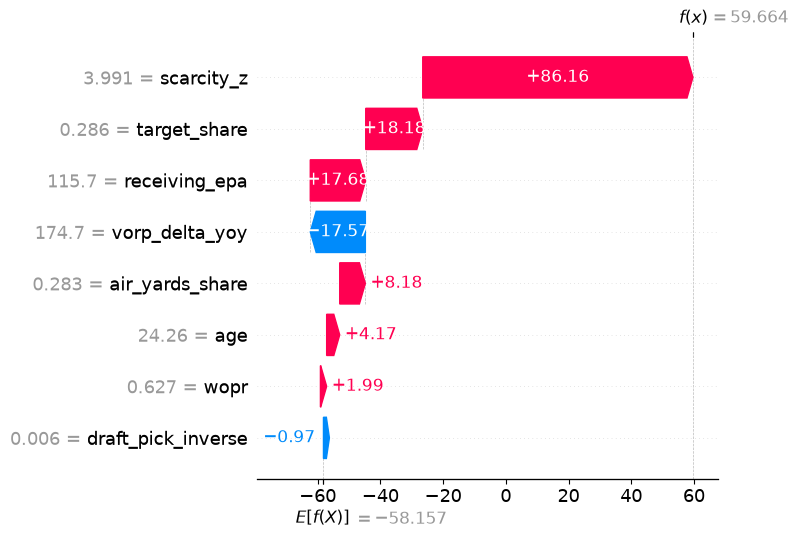


=== Jaxon Smith-Njigba ===
Predicted 2026 VORP: 74.380   (base -58.157 + sum(SHAP) = 74.380)
           feature   value      shap
        scarcity_z   3.833 94.209999
      target_share   0.358 13.000000
              wopr   0.878  9.334000
     receiving_epa  90.672  8.560000
draft_pick_inverse   0.050  8.280000
    vorp_delta_yoy 128.700 -5.242000
   air_yards_share   0.487  2.834000
               age  23.546  1.560000


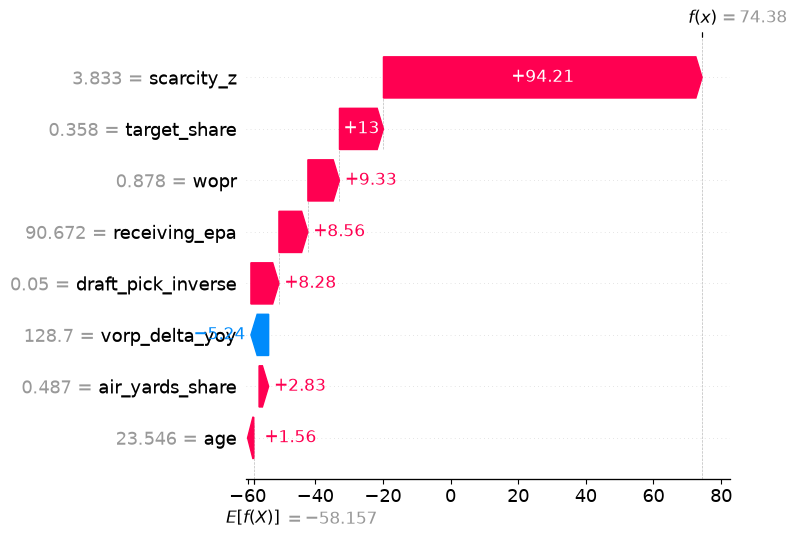


=== George Pickens ===
Predicted 2026 VORP: 78.992   (base -58.157 + sum(SHAP) = 78.992)
           feature   value       shap
        scarcity_z   2.968  92.419998
     receiving_epa  88.743  24.357000
    vorp_delta_yoy 141.800 -11.650000
   air_yards_share   0.305  10.327000
              wopr   0.552   9.249000
               age  24.496   7.636000
      target_share   0.226   5.380000
draft_pick_inverse   0.019  -0.570000


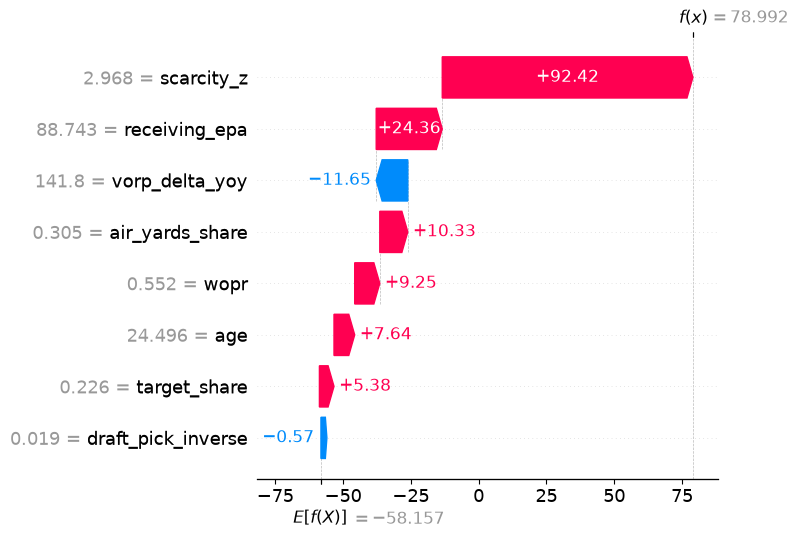

In [4]:
names = ["Puka Nacua", "Jaxon Smith-Njigba", "George Pickens"]
top5_2025 = wr_2025_features.set_index("player_display_name")

local_shap = {}
for name in names:
    row = top5_2025.loc[name, FEATURES]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    local_shap[name] = sv
    pred = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    print(f"=== {name} ===")
    print(f"Predicted 2026 VORP: {pred:.3f}   (base {explainer.expected_value:.3f} + sum(SHAP) = {explainer.expected_value + sv.values[0].sum():.3f})")
    contrib = pd.DataFrame({"feature": FEATURES, "value": row.to_numpy(), "shap": sv.values[0]}).sort_values("shap", key=np.abs, ascending=False)
    print(contrib.round(3).to_string(index=False))
    shap.plots.waterfall(sv[0], show=False)
    plt.tight_layout()
    plt.show()
    print()


**Internally consistent for all three rows.** `base + sum(SHAP)` reproduces the printed predicted VORP exactly for Nacua (59.664), Smith-Njigba (74.380), and Pickens (78.992).

**A real correction to `06c_model_wr.ipynb`'s own framing: `vorp_delta_yoy` is not actually the dominant driver of any of these three predictions — `scarcity_z` is, by a wide margin.** `06c`'s prose read these as "the model is reading a huge one-year jump and calling for reversion," which puts the emphasis on `vorp_delta_yoy`. SHAP tells a different story: `scarcity_z` contributes +86.2 (Nacua), +94.2 (Smith-Njigba), and +92.4 (Pickens) — the single largest driver in every row by a wide margin, dwarfing `vorp_delta_yoy`'s own contribution (-17.6, -5.2, and -11.7 respectively). `vorp_delta_yoy`'s contribution is real and consistently negative (correctly pointing toward decline, in the direction the flag implies), but it is a **secondary correction on top of an already-dominant `scarcity_z` pull**, not the main force producing these predictions.

**The three flagged players do scale together in a simple way, at least among themselves**: ranked by raw delta, Nacua (174.7) > Pickens (141.8) > Smith-Njigba (128.7), and their `vorp_delta_yoy` contributions rank the same way (-17.6, -11.7, -5.2 respectively). Three points aren't enough to characterize the full shape of that relationship — Mystery 1 below tests it properly, across the whole training set — but nothing in these three rows contradicts a monotonic "bigger delta, bigger correction" pattern on its own.

**Bottom line: the flag is correctly identifying real uncertainty in these three predictions, but the mental model of *why* they're uncertain needs updating.** It is not "a huge delta is overriding everything else and forcing a decline call" — it is "`scarcity_z` sets a strong baseline, and `vorp_delta_yoy` adds a real but secondary downward correction whose size doesn't scale simply with the raw delta."

## Reusable function: `explain_player`

Verbatim copy of `08a_shap_qb.ipynb`'s function — its body only ever references `FEATURES`, `model`, `explainer`, and `ALL_ROWS`, never anything QB-specific by name, so it works unchanged here once this notebook's own WR globals are in scope. This is the third position running this exact function without modification (after RB in `08b_shap_rb.ipynb`), which is itself the real confirmation that it generalizes cleanly across positions with just a different model/feature list, rather than needing a parameterized rewrite.

In [5]:
ALL_ROWS = pd.concat([wr, wr_2025_features], ignore_index=True)


def explain_player(player_name, season, top_n=5):
    """Returns the top N features driving wr_model.json's prediction for a given
    player-season, ranked by absolute SHAP contribution, with signed value and direction."""
    match = ALL_ROWS[(ALL_ROWS["player_display_name"] == player_name) & (ALL_ROWS["season"] == season)]
    if match.empty:
        raise ValueError(f"No WR row found for {player_name}, season {season}")
    row = match[FEATURES].iloc[0]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    prediction = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    contrib = pd.DataFrame({
        "feature": FEATURES,
        "feature_value": row.to_numpy(),
        "shap_value": sv.values[0],
    })
    contrib["direction"] = np.where(contrib["shap_value"] >= 0, "increases", "decreases")
    contrib["abs_shap"] = contrib["shap_value"].abs()
    top_5_drivers = contrib.sort_values("abs_shap", ascending=False).head(top_n).drop(columns="abs_shap").reset_index(drop=True)

    print(f"{player_name} ({season} season -> {season + 1} prediction)")
    print(f"Predicted VORP: {prediction:.2f}   Base value: {explainer.expected_value:.2f}")
    print(top_5_drivers.round(3).to_string(index=False))
    return top_5_drivers


In [6]:
# Test cases: the two unflagged members of WR's own top-5-by-2025-VORP group, Amon-Ra
# St. Brown and Ja'Marr Chase -- real rows already discussed in 06c_model_wr.ipynb but not
# covered by the waterfalls above, rather than picked from elsewhere in the dataset.
_ = explain_player("Amon-Ra St. Brown", 2025)
print()
_ = explain_player("Ja'Marr Chase", 2025)


Amon-Ra St. Brown (2025 season -> 2026 prediction)
Predicted VORP: 81.88   Base value: -58.16
        feature  feature_value  shap_value direction
     scarcity_z          3.284  106.914001 increases
           wopr          0.730   17.898001 increases
  receiving_epa         55.615   15.027000 increases
   target_share          0.313   13.430000 increases
air_yards_share          0.372   -8.954000 decreases

Ja'Marr Chase (2025 season -> 2026 prediction)
Predicted VORP: 76.33   Base value: -58.16
       feature  feature_value  shap_value direction
    scarcity_z          3.058   91.429001 increases
  target_share          0.304   12.817000 increases
vorp_delta_yoy        -57.100   10.383000 increases
 receiving_epa         41.379    9.043000 increases
          wopr          0.690    4.797000 increases


**Both test cases resolve correctly, completing coverage of all five members of WR's top-5-by-2025-VORP group** (three via the waterfalls above, two here). Amon-Ra St. Brown's prediction (81.88) is driven overwhelmingly by `scarcity_z` (+106.9, the highest single contribution seen anywhere in this notebook, consistent with his `scarcity_z` of 3.284 being the highest of the whole top-5 group) plus smaller positive contributions from `wopr`, `receiving_epa`, and `target_share`; `air_yards_share` is actually a small *negative* contributor (-9.0) for him, a reminder that not every feature moves in the "obvious" direction for every row. Ja'Marr Chase's prediction (76.33) is led by `scarcity_z` (+91.4) as well, with `vorp_delta_yoy` this time contributing *positively* (+10.4) — correctly reflecting his negative raw delta (-57.1, a down 2025 relative to 2024) and consistent with the strong overall negative correlation between delta and SHAP found in Mystery 1 below.

`explain_player` required no changes to resolve either row, the third position running this exact function unmodified after QB and RB.

## Mystery 1 replication: the `vorp_delta_yoy` extreme-tail mechanism

**This section is a direct test of whether QB's finding is a general tree-ensemble property or something specific to QB, not just another replication for its own sake.** `08a_shap_qb.ipynb` found that QB's `vorp_delta_yoy` SHAP contribution saturates once `|delta|` passes roughly 100—150 — steep and close to linear in the normal range, then flattening at both extremes rather than continuing to grow. `08b_shap_rb.ipynb` could not cleanly test whether this generalizes, because RB's `vorp_delta_yoy` carries a `+1` monotonic constraint that forces non-decreasing behavior by construction — a confound that fully explained RB's different-looking curve on its own, independent of whether tree saturation is real or universal.

**WR removes that confound.** Confirmed directly against `06c_model_wr.ipynb`'s own model-saving cell: `wr_model.json` is trained with `monotone_constraints=NO_CONSTRAINTS`, fully unconstrained across all 8 features, including `vorp_delta_yoy` — the same tuning regime as `qb_model.json`. That makes this the first real apples-to-apples replication attempt: **if WR's curve also saturates, that is genuine, independent confirmation the mechanism is a general tree-ensemble property, not a QB-specific artifact. If it doesn't saturate the same way, then QB's finding does not generalize even among unconstrained models, and needs a different explanation than "this is just how gradient-boosted trees represent continuous features."** Both outcomes are reported plainly below, whichever one the evidence actually shows.

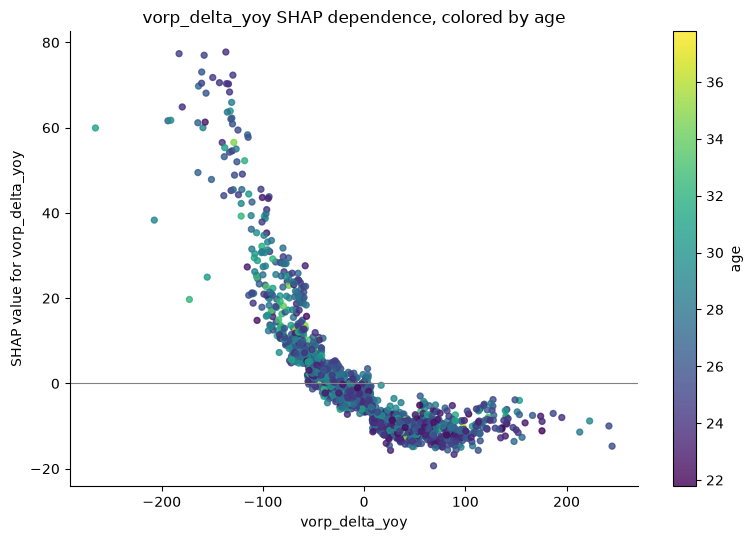

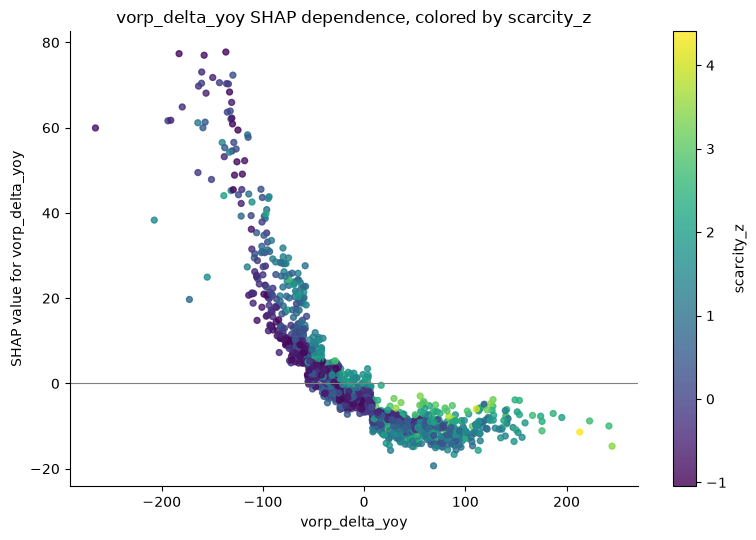

In [7]:
feat_idx = {f: i for i, f in enumerate(FEATURES)}
sv_arr = shap_values.values


def dependence_plot(x_feat, color_feat, title):
    x = wr[x_feat].to_numpy()
    y = sv_arr[:, feat_idx[x_feat]]
    c = wr[color_feat].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sca = ax.scatter(x, y, c=c, cmap="viridis", s=18, alpha=0.8)
    cb = plt.colorbar(sca, ax=ax)
    cb.set_label(color_feat)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(f"SHAP value for {x_feat}")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


dependence_plot("vorp_delta_yoy", "age", "vorp_delta_yoy SHAP dependence, colored by age")
dependence_plot("vorp_delta_yoy", "scarcity_z", "vorp_delta_yoy SHAP dependence, colored by scarcity_z")


In [8]:
d = pd.DataFrame({
    "delta": wr["vorp_delta_yoy"], "shap": sv_arr[:, feat_idx["vorp_delta_yoy"]],
    "age": wr["age"], "scarcity_z": wr["scarcity_z"],
}).dropna()

d["bucket"] = pd.cut(d["delta"], bins=[-1000, -200, -100, -50, 0, 50, 100, 200, 1000])
print("Mean SHAP value by delta bucket:")
print(d.groupby("bucket", observed=True)["shap"].agg(["count", "mean", "std"]).round(2).to_string())

overall_corr = np.corrcoef(d["delta"], d["shap"])[0, 1]
young = d[d["age"] < d["age"].median()]
old = d[d["age"] >= d["age"].median()]
print(f"\nOverall correlation(delta, shap): {overall_corr:.3f}")
print(f"Correlation among younger half (age < {d['age'].median():.1f}): {np.corrcoef(young['delta'], young['shap'])[0, 1]:.3f}")
print(f"Correlation among older half: {np.corrcoef(old['delta'], old['shap'])[0, 1]:.3f}")


Mean SHAP value by delta bucket:
               count       mean    std
bucket                                
(-1000, -200]      2  49.130001  15.29
(-200, -100]      78  47.750000  17.65
(-100, -50]      266  13.840000   9.01
(-50, 0]         662  -0.880000   3.46
(0, 50]          593  -8.100000   2.99
(50, 100]        245 -10.730000   2.43
(100, 200]        79  -9.220000   2.70
(200, 1000]        4 -11.230000   2.56

Overall correlation(delta, shap): -0.799
Correlation among younger half (age < 26.1): -0.771
Correlation among older half: -0.823


**Outcome: YES — WR shows the same saturating pattern QB did, in a genuine, same-tuning-regime replication. This is real, independent confirmation that Mystery 1 is a general tree-ensemble property, not a QB-specific artifact.**

| bucket | count | mean SHAP | std |
|---|---|---|---|
| (-1000, -200] | 2 | +49.13 | 15.29 |
| (-200, -100] | 78 | +47.75 | 17.65 |
| (-100, -50] | 266 | +13.84 | 9.01 |
| (-50, 0] | 662 | -0.88 | 3.46 |
| (0, 50] | 593 | -8.10 | 2.99 |
| (50, 100] | 245 | -10.73 | 2.43 |
| (100, 200] | 79 | -9.22 | 2.70 |
| (200, 1000] | 4 | -11.23 | 2.56 |

The shape is the same steep-middle, flat-tails curve QB showed. The steep region sits between roughly -100 and +50 (dropping from +13.84 to -8.10, most of the curve's total movement), and **both tails flatten**: on the negative side, (-200,-100] and (-1000,-200] land at nearly identical values (47.75 and 49.13) despite covering wildly different delta magnitudes — and unlike RB's version of this check, this plateau is well-supported (78 rows in the first of those two buckets, not just the thin far-tail bucket). On the positive side, (50,100], (100,200], and (200,1000] all cluster tightly between -9.22 and -11.23 across 328 rows combined — clearly flat, not still climbing the way RB's sparse positive tail was.

`correlation(delta, shap) = -0.799` overall, with no meaningful age interaction (young half -0.771, old half -0.823, essentially the same split QB showed with no age effect).

**Verdict, stated plainly: Mystery 1 replicates.** WR is unconstrained on `vorp_delta_yoy`, the same tuning regime as QB, and shows the same qualitative saturating S-shape, with good sample sizes supporting the flattening on both tails, not just the sparse-extreme-bucket problem that limited RB's version of this check. This is the confirmation the section set out to test: the mechanism generalizes across at least two independently-tuned, unconstrained models, supporting it as a genuine tree-ensemble property rather than something specific to QB's data or feature set.

## Mystery 2 replication: the `scarcity_z` top-decile difficulty

`08a_shap_qb.ipynb` found QB's `scarcity_z` dependence curve smooth and monotonic across its full range, with no visible break or fan-out specifically at the top decile — an inconclusive result against `roadmap.md`'s documented held-out MAE degradation there. `08b_shap_rb.ipynb` found a more visible version of the same pattern for RB (a real 3—4x variance jump across its top ~30% of `scarcity_z`), and floated a specific, testable hypothesis: RB's smaller feature set (4 features vs. QB's 6) means less competition for the tree ensemble's limited splits, which could make a real top-end pattern more visible in SHAP terms. **WR is the natural next test of that hypothesis in the other direction**: with 8 features, WR has *more* competition for splits than either QB or RB, not less. If the smaller-feature-set hypothesis is right, WR's top-decile pattern should be the least visible of the three positions checked so far, not the most — that is a direct, falsifiable prediction, not just another data point to describe after the fact.

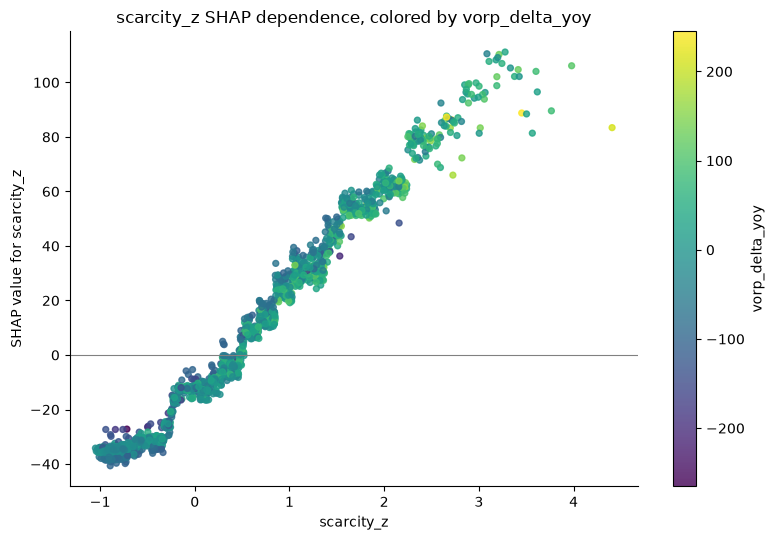

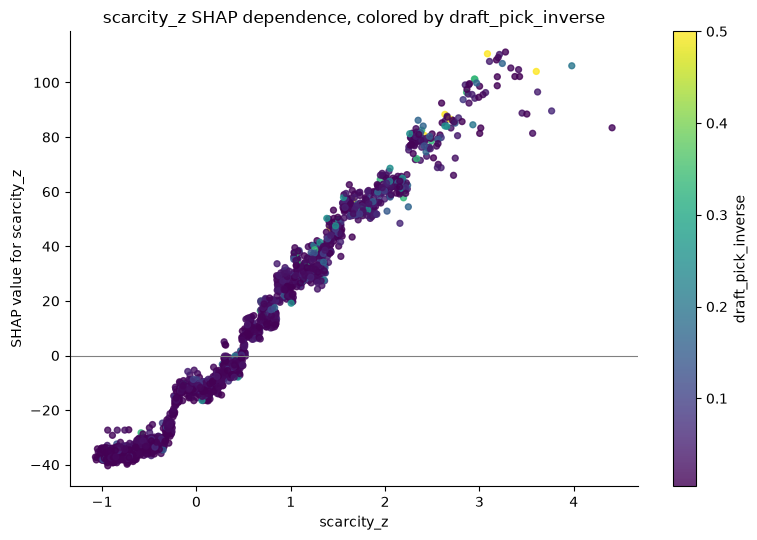

In [9]:
dependence_plot("scarcity_z", "vorp_delta_yoy", "scarcity_z SHAP dependence, colored by vorp_delta_yoy")
dependence_plot("scarcity_z", "draft_pick_inverse", "scarcity_z SHAP dependence, colored by draft_pick_inverse")


In [10]:
s = pd.DataFrame({
    "scarcity_z": wr["scarcity_z"], "shap": sv_arr[:, feat_idx["scarcity_z"]],
    "delta": wr["vorp_delta_yoy"], "draft_pick_inverse": wr["draft_pick_inverse"],
})
s["decile"] = pd.qcut(s["scarcity_z"], 10, labels=False, duplicates="drop")
print("SHAP value by scarcity_z decile:")
print(s.groupby("decile")["shap"].agg(["count", "mean", "std"]).round(2).to_string())

top_decile = s[s["decile"] == s["decile"].max()]
corr_draft = np.corrcoef(top_decile["draft_pick_inverse"].fillna(0), top_decile["shap"])[0, 1]
corr_delta = np.corrcoef(top_decile["delta"].fillna(0), top_decile["shap"])[0, 1]
print(f"\nWithin the top scarcity_z decile (n={len(top_decile)}):")
print(f"  correlation(draft_pick_inverse, shap) = {corr_draft:.3f}")
print(f"  correlation(vorp_delta_yoy, shap) = {corr_delta:.3f}")


SHAP value by scarcity_z decile:
        count       mean    std
decile                         
0         274 -36.570000   1.51
1         273 -36.119999   1.77
2         273 -34.830002   2.30
3         273 -31.900000   2.31
4         273 -16.100000   5.62
5         273 -10.450000   3.42
6         273   2.910000   7.67
7         273  23.090000   7.39
8         273  42.790001  10.07
9         273  71.750000  15.21

Within the top scarcity_z decile (n=273):
  correlation(draft_pick_inverse, shap) = 0.167
  correlation(vorp_delta_yoy, shap) = 0.166


**Outcome: the smaller-feature-set hypothesis is falsified, not confirmed, by WR's result.** The hypothesis (raised in `08b_shap_rb.ipynb`) predicted WR — with 8 features, the most of any position checked, and therefore the most competition for the tree ensemble's limited splits — should show the *least* visible top-decile pattern of the three. It shows the *most* visible instead.

| decile | count | mean SHAP | std |
|---|---|---|---|
| 0 (bottom) | 274 | -36.57 | 1.51 |
| 1 | 273 | -36.12 | 1.77 |
| 2 | 273 | -34.83 | 2.30 |
| 3 | 273 | -31.90 | 2.31 |
| 4 | 273 | -16.10 | 5.62 |
| 5 | 273 | -10.45 | 3.42 |
| 6 | 273 | +2.91 | 7.67 |
| 7 | 273 | +23.09 | 7.39 |
| 8 | 273 | +42.79 | 10.07 |
| 9 (top) | 273 | +71.75 | **15.21** |

The bottom-quartile std band (1.51—2.31) jumps to **15.21** at the actual top decile — roughly a **6—7x increase**, and unlike RB, the single highest-variance decile really is the top one, not a runner-up. That is a bigger relative jump than RB's ~3—4x and far bigger than QB's ~1.1x.

**Ranking the three positions by feature count against the size of this effect gives the opposite order the hypothesis predicted**: RB (4 features) showed a moderate 3—4x jump, QB (6 features) showed almost none (1.1x), and WR (8 features, the most) showed the largest jump of all (6—7x). Feature count and split competition do not explain the pattern — if anything the relationship runs backwards from what was proposed. Within WR's own top decile, the secondary correlations are weak either way (`draft_pick_inverse` 0.167, `vorp_delta_yoy` 0.166), similar in size to RB's (-0.160, +0.184) and both much weaker than QB's -0.518, so WR doesn't show a stronger secondary interaction either, just a bigger primary variance effect.

**Verdict, stated plainly rather than rescued: the smaller-feature-set/more-competition hypothesis is falsified by this test.** Whatever actually drives how visible this pattern is in SHAP terms, it is not simply a function of how many features the model has to split among. This is reported as an honest falsification, not reframed as a partial win — the real driver remains an open question this notebook does not resolve.

## Summary

**Global ranking: the most SHAP/gain disagreement of the three positions.** WR agrees with gain importance only at the very top (`scarcity_z`) and bottom (`draft_pick_inverse`); the six middle features reorder substantially, most sharply `receiving_epa` (SHAP 2nd, gain 7th) and `wopr` (SHAP 5th, gain 2nd) — a bigger disagreement than QB's single #2/#3 flip, and a sharp contrast with RB's perfect agreement.

**The three flagged predictions' real driver is `scarcity_z`, not `vorp_delta_yoy` as `06c_model_wr.ipynb`'s own prose assumed.** For Nacua, Smith-Njigba, and Pickens alike, `scarcity_z` contributes +86 to +94 points — the dominant force in every row — while `vorp_delta_yoy` adds a real but clearly secondary negative correction (-5.2 to -17.6) that does not scale simply with the raw delta size. The flag is catching real uncertainty, but the story behind it needed correcting.

**`explain_player` needed zero changes for a third straight position**, confirmed on Amon-Ra St. Brown and Ja'Marr Chase, completing coverage of WR's entire top-5 group between the waterfalls above and this section.

**Mystery 1 replicates: genuine, independent confirmation.** WR is confirmed unconstrained on `vorp_delta_yoy`, the same regime as QB, and shows the same steep-middle/flat-tails saturating curve, well-supported by real sample sizes on both tails. This is the strongest evidence yet that the tree-saturation mechanism is a general property, not specific to QB.

**Mystery 2's smaller-feature-set hypothesis is falsified.** WR, with the most features (8) of any position checked, shows the *largest* top-decile variance jump (6—7x) rather than the smallest as the hypothesis predicted, with RB (4 features, ~3—4x) and QB (6 features, ~1.1x) landing in between and lowest respectively — the opposite order feature-count competition would predict. Reported here as an honest falsification: whatever drives this pattern's visibility, it isn't simply how many features the model has to split among.